# 01 — Data Pipeline
## Uzbekistan Power Sector Transition Tracker
**ILF Consulting Engineers Austria — Capstone Project**

---

### Purpose
This notebook builds the **master dataset** that powers all downstream analysis, forecasting, and the dashboard. It:
1. Loads raw data from four sources: IEA, StatSUZ Uzbekistan, IRENA, and World Bank
2. Standardises units across all sources (everything electricity → TWh)
3. Extracts only the variables relevant to the project
4. Merges everything into a single annual time series from **1990 to 2024**
5. Flags preliminary years (2024–2026) clearly
6. Exports a clean `master_dataset.csv` for use in all subsequent notebooks

### Data Sources & Folder Structure
```
data/raw/
  emissions (source - IEA)/          ← CO2 intensity, emissions by sector
  energy consumption data (source - IEA)/  ← electricity consumption by sector
  energy imports and exports (source - IEA)/  ← net imports
  energy production data (source - IEA)/  ← generation by fuel, TES, gas
  energy production data (source - IRENA)/ ← RE capacity & generation
  socioeconomic macro indicators (source - World Bank)/  ← GDP, population, CO2
  statsuz/                           ← capacity, solar, wind, gas (extends to 2024)
  power plants (source - World Bank)/ ← GeoJSON files for mapping
```

> **Note:** Years 2024–2026 are preliminary estimates in some IEA series and are labelled with `is_preliminary = 1`.

---
## 0. Setup — Libraries and Paths

In [41]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:,.3f}'.format)
pd.set_option('display.max_rows', 40)

print('Libraries loaded.')

Libraries loaded.


In [42]:
# ── Paths ─────────────────────────────────────────────────────────────────────
# Notebook is inside notebooks/ so we use ../ to go up one level
DATA_PROCESSED = '../data/processed'
os.makedirs(DATA_PROCESSED, exist_ok=True)

PATH_IEA_EMISSIONS   = '../data/raw/emissions (source - IEA)'
PATH_IEA_CONSUMPTION = '../data/raw/energy consumption data (source - IEA)'
PATH_IEA_IMPORTS     = '../data/raw/energy imports and exports (source - IEA)'
PATH_IEA_PRODUCTION  = '../data/raw/energy production data (source - IEA)'
PATH_IRENA           = '../data/raw/energy production data (source - IRENA)'
PATH_WORLDBANK       = '../data/raw/socioeconomic macro indicators (source - World Bank)'
PATH_STATSUZ         = '../data/raw/statsuz'
PATH_POWER_PLANTS    = '../data/raw/power plants (source - World Bank)'

# ── Year range ────────────────────────────────────────────────────────────────
YEAR_START        = 1990
YEAR_END          = 2026
PRELIMINARY_YEARS = [2024, 2025, 2026]

print(f'Output: {DATA_PROCESSED}')
print(f'Year range: {YEAR_START}–{YEAR_END}')
print()

# ── Confirm all source folders exist ─────────────────────────────────────────
for name, path in [
    ('IEA emissions',   PATH_IEA_EMISSIONS),
    ('IEA consumption', PATH_IEA_CONSUMPTION),
    ('IEA imports',     PATH_IEA_IMPORTS),
    ('IEA production',  PATH_IEA_PRODUCTION),
    ('IRENA',           PATH_IRENA),
    ('World Bank',      PATH_WORLDBANK),
    ('StatSUZ',         PATH_STATSUZ),
]:
    icon = '✓' if os.path.isdir(path) else '✗ MISSING'
    print(f'  {icon}  {name}')

Output: ../data/processed
Year range: 1990–2026

  ✓  IEA emissions
  ✓  IEA consumption
  ✓  IEA imports
  ✓  IEA production
  ✓  IRENA
  ✓  World Bank
  ✓  StatSUZ


---
## 1. Helper Functions

Each source has a different file format. We define one loader per source.

- **IEA** — CSV with 3-row licence header, years as row index
- **StatSUZ** — CSV with readable names, wide format (years as columns), first data row = national total
- **IRENA** — long format CSV, filtered for Uzbekistan, pivoted to wide
- **World Bank** — XLSX with series codes as rows, year columns like `1990 [YR1990]`

In [43]:
def load_iea(filename, folder, col_rename=None):
    filepath = os.path.join(folder, filename)
    if not os.path.isfile(filepath):
        print(f'  ✗ NOT FOUND: {filepath}')
        return pd.DataFrame()

    df = pd.read_csv(filepath, skiprows=3, index_col=0)
    if 'Units' in df.columns:
        df = df.drop(columns=['Units'])

    df.index = pd.to_numeric(df.index, errors='coerce')
    df = df.dropna(how='all')
    df.index = df.index.astype(int)
    df = df.loc[(df.index >= YEAR_START) & (df.index <= YEAR_END)]  # ← FIXED
    df = df.apply(pd.to_numeric, errors='coerce')

    if col_rename:
        df = df.rename(columns=col_rename)
    df.index.name = 'year'
    return df


def load_statsuz(filename, value_name='value'):
    filepath = os.path.join(PATH_STATSUZ, filename)
    if not os.path.isfile(filepath):
        print(f'  ✗ NOT FOUND: {filepath}')
        return pd.Series(dtype=float, name=value_name)

    try:
        df = pd.read_csv(filepath, encoding='utf-8-sig')
    except Exception:
        df = pd.read_csv(filepath, encoding='cp1251')

    year_cols = [c for c in df.columns
                 if str(c).strip().isdigit() and len(str(c).strip()) == 4]

    if not year_cols:
        print(f'  ✗ No year columns found in {filename}')
        print(f'    Columns seen: {list(df.columns[:6])}')
        return pd.Series(dtype=float, name=value_name)

    row = df[year_cols].iloc[0]
    series = pd.to_numeric(row, errors='coerce')
    series.index = series.index.astype(int)
    series = series[(series.index >= YEAR_START) & (series.index <= YEAR_END)]  # ← FIXED
    series.name = value_name
    series.index.name = 'year'
    return series


def load_worldbank(series_codes):
    filepath = os.path.join(
        PATH_WORLDBANK,
        'P_Data_Extract_From_World_Development_Indicators.xlsx'
    )
    if not os.path.isfile(filepath):
        print(f'  ✗ NOT FOUND: {filepath}')
        return pd.DataFrame()

    df = pd.read_excel(filepath, sheet_name='Data')
    df = df[df['Series Code'].isin(series_codes.keys())]

    year_cols = [c for c in df.columns if '[YR' in str(c)]
    year_ints  = [int(str(c).split(' ')[0]) for c in year_cols]

    frames = []
    for wb_code, col_name in series_codes.items():
        row = df[df['Series Code'] == wb_code]
        if row.empty:
            print(f'  ✗ WB series not found: {wb_code}')
            continue
        values = pd.to_numeric(row[year_cols].iloc[0].values, errors='coerce')
        s = pd.Series(values, index=year_ints, name=col_name)
        s = s[(s.index >= YEAR_START) & (s.index <= YEAR_END)]  # ← FIXED
        s.index.name = 'year'
        frames.append(s)

    return pd.concat(frames, axis=1) if frames else pd.DataFrame()


print('✓ Helper functions ready.')

✓ Helper functions ready.


---
## 2. Load IEA Data

In [44]:
print('Loading IEA data...')
print('=' * 60)

# ── 2.1 Electricity generation by fuel source (GWh) ──────────────────────────
iea_elec_gen = load_iea(
    'Electricity generation by source - Uzbekistan.csv',
    folder=PATH_IEA_PRODUCTION,
    col_rename={
        'Coal':        'gen_coal_gwh',
        'Oil':         'gen_oil_gwh',
        'Natural gas': 'gen_gas_gwh',
        'Hydropower':  'gen_hydro_gwh',
        'Solar PV':    'gen_solar_gwh',
        'Wind':        'gen_wind_gwh',
    }
)
print(f'✓ Electricity generation by source: {iea_elec_gen.shape[0]} years, columns: {list(iea_elec_gen.columns)}')

# ── 2.2 Total electricity consumption (GWh) ───────────────────────────────────
iea_elec_consumption = load_iea(
    'Electricity consumption - Uzbekistan.csv',
    folder=PATH_IEA_CONSUMPTION,
    col_rename={'Electricity consumption': 'elec_consumption_gwh'}
)
print(f'✓ Electricity consumption: {iea_elec_consumption.shape}')

# ── 2.3 Electricity consumption by sector (TJ) ────────────────────────────────
iea_elec_sector = load_iea(
    'Electricity consumption by sector - Uzbekistan.csv',
    folder=PATH_IEA_CONSUMPTION,
    col_rename={
        'Industry':                       'elec_industry_tj',
        'Transport':                      'elec_transport_tj',
        'Residential':                    'elec_residential_tj',
        'Commercial and public services': 'elec_commercial_tj',
        'Agriculture and forestry':       'elec_agriculture_tj',
    }
)
print(f'✓ Electricity by sector: {iea_elec_sector.shape}')

# ── 2.4 Electricity per capita ────────────────────────────────────────────────
iea_elec_pc = load_iea(
    'Electricity consumption per capita - Uzbekistan.csv',
    folder=PATH_IEA_CONSUMPTION,
    col_rename={'Electricity consumption per capita': 'elec_per_capita_mwh'}
)
print(f'✓ Electricity per capita: {iea_elec_pc.shape}')

# ── 2.5 Natural gas production (TJ gross) ─────────────────────────────────────
iea_gas_prod = load_iea(
    'Natural gas production - Uzbekistan.csv',
    folder=PATH_IEA_PRODUCTION,
    col_rename={'Natural gas': 'gas_production_tj'}
)
print(f'✓ Gas production: {iea_gas_prod.shape}')

# ── 2.6 Natural gas final consumption (TJ gross) ──────────────────────────────
iea_gas_cons = load_iea(
    'Natural gas final consumption - Uzbekistan.csv',
    folder=PATH_IEA_CONSUMPTION,
    col_rename={'Natural gas': 'gas_consumption_tj'}
)
print(f'✓ Gas consumption: {iea_gas_cons.shape}')

# ── 2.7 Total energy supply by source (TJ) ────────────────────────────────────
iea_tes = load_iea(
    'Total energy supply (TES) by source - Uzbekistan.csv',
    folder=PATH_IEA_PRODUCTION
)
print(f'✓ Total energy supply (TES): {iea_tes.shape}')

# ── 2.8 Net energy imports (TJ) ───────────────────────────────────────────────
iea_net_imports = load_iea(
    'Net energy imports - Uzbekistan.csv',
    folder=PATH_IEA_IMPORTS,
    col_rename={'Net energy imports': 'net_energy_imports_tj'}
)
print(f'✓ Net energy imports: {iea_net_imports.shape}')

# ── 2.9 CO2 emissions by sector ───────────────────────────────────────────────
iea_co2_sector = load_iea(
    'CO2 emissions by sector - Uzbekistan.csv',
    folder=PATH_IEA_EMISSIONS
)
print(f'✓ CO2 by sector: {iea_co2_sector.shape}')

# ── 2.10 CO2 intensity of power sector (gCO2/kWh) ────────────────────────────
iea_co2_power = load_iea(
    'CO2 intensity of power - Uzbekistan.csv',
    folder=PATH_IEA_EMISSIONS,
    col_rename={'CO2 intensity of power': 'co2_intensity_power_gco2kwh'}
)
print(f'✓ CO2 intensity of power: {iea_co2_power.shape}')

print('\n✓ All IEA files loaded.')

Loading IEA data...
✓ Electricity generation by source: 34 years, columns: ['gen_coal_gwh', 'gen_oil_gwh', 'gen_gas_gwh', 'gen_hydro_gwh', 'gen_solar_gwh', 'gen_wind_gwh']
✓ Electricity consumption: (34, 1)
✓ Electricity by sector: (34, 6)
✓ Electricity per capita: (34, 1)
✓ Gas production: (34, 1)
✓ Gas consumption: (34, 1)
✓ Total energy supply (TES): (34, 6)
✓ Net energy imports: (34, 1)
✓ CO2 by sector: (34, 9)
✓ CO2 intensity of power: (34, 1)

✓ All IEA files loaded.


---
## 3. Load StatSUZ Data

StatSUZ provides the most up-to-date figures, extending IEA series to **2024**. It also has installed capacity and renewable production data not available in IEA.

Files are in `data/raw/statsuz/` with human-readable names.

In [45]:
print('Loading StatSUZ data...')
print('=' * 60)

# ── 3.1 Total electricity production (mln kWh = GWh) ─────────────────────────
sc_elec_prod = load_statsuz(
    'Volume of electricity production.csv',
    value_name='sc_elec_prod_gwh'
)
print(f'✓ Electricity production: {len(sc_elec_prod)} years ({sc_elec_prod.index.min()}–{sc_elec_prod.index.max()})')

# ── 3.2 Total electricity supply (mln kWh = GWh) ─────────────────────────────
sc_elec_supply = load_statsuz(
    'Volume of electricity supply.csv',
    value_name='sc_elec_supply_gwh'
)
print(f'✓ Electricity supply: {len(sc_elec_supply)} years')

# ── 3.3 Total installed capacity — all power plants (MW) ─────────────────────
sc_capacity_total = load_statsuz(
    'Total installed capacity of power plants.csv',
    value_name='capacity_total_mw'
)
print(f'✓ Total installed capacity: {len(sc_capacity_total)} years')

# ── 3.4 Installed capacity — hydroelectric (MW) ───────────────────────────────
sc_capacity_hydro = load_statsuz(
    'Total installed capacity of hydroelectric power plants.csv',
    value_name='capacity_hydro_mw'
)
print(f'✓ Hydro capacity: {len(sc_capacity_hydro)} years')

# ── 3.5 Installed capacity — thermal (MW) ─────────────────────────────────────
sc_capacity_thermal = load_statsuz(
    'Total installed capacity of thermal power centers and thermal power plants.csv',
    value_name='capacity_thermal_mw'
)
print(f'✓ Thermal capacity: {len(sc_capacity_thermal)} years')

# ── 3.6 Solar electricity production (mln kWh = GWh) ─────────────────────────
sc_solar = load_statsuz(
    'Volume of electricity produced by solar power plants.csv',
    value_name='sc_solar_gwh'
)
print(f'✓ Solar production: {len(sc_solar)} years')

# ── 3.7 Wind electricity production (mln kWh = GWh) ──────────────────────────
sc_wind = load_statsuz(
    'Volume of electricity produced by wind power farms.csv',
    value_name='sc_wind_gwh'
)
print(f'✓ Wind production: {len(sc_wind)} years')

# ── 3.8 Natural gas production (mln m³) ───────────────────────────────────────
sc_gas_prod = load_statsuz(
    'Volume of natural gas production.csv',
    value_name='sc_gas_prod_mcm'
)
print(f'✓ Gas production: {len(sc_gas_prod)} years')

# ── 3.9 Natural gas consumption (mln m³) ──────────────────────────────────────
sc_gas_cons = load_statsuz(
    'Volume of natural gas consumption.csv',
    value_name='sc_gas_cons_mcm'
)
print(f'✓ Gas consumption: {len(sc_gas_cons)} years')

# ── 3.10 Coal production ──────────────────────────────────────────────────────
sc_coal_prod = load_statsuz(
    'Volume of coal production.csv',
    value_name='sc_coal_prod'
)
print(f'✓ Coal production: {len(sc_coal_prod)} years')

# ── 3.11 Electricity supply by sector ────────────────────────────────────────
sc_elec_industry  = load_statsuz('Volume of electricity supply in the industrial sector.csv',  value_name='sc_elec_industry_gwh')
sc_elec_agri      = load_statsuz('Volume of electricity supply in agricultural sector.csv',     value_name='sc_elec_agriculture_gwh')
sc_elec_transport = load_statsuz('Volume of electricity supply in transport sector.csv',        value_name='sc_elec_transport_gwh')
sc_elec_housing   = load_statsuz('Volume of electricity supply in housing sector.csv',          value_name='sc_elec_housing_gwh')
print(f'✓ Sectoral electricity: industry, agriculture, transport, housing')

print('\n✓ All StatSUZ files loaded.')

# ── Validation: catch any completely empty series ─────────────────────────────
print('\nStatSUZ validation:')
for name, s in [
    ('sc_elec_prod',     sc_elec_prod),
    ('sc_elec_supply',   sc_elec_supply),
    ('capacity_total',   sc_capacity_total),
    ('capacity_hydro',   sc_capacity_hydro),
    ('capacity_thermal', sc_capacity_thermal),
    ('sc_solar',         sc_solar),
    ('sc_wind',          sc_wind),
    ('sc_gas_prod',      sc_gas_prod),
]:
    if len(s) == 0 or s.isna().all():
        print(f'  ⚠️  {name} is EMPTY — check filename')
    else:
        print(f'  ✓  {name}: latest = {s.iloc[-1]:,.1f} ({s.index[-1]})')

Loading StatSUZ data...
✓ Electricity production: 15 years (2010–2024)
✓ Electricity supply: 15 years
✓ Total installed capacity: 15 years
✓ Hydro capacity: 15 years
✓ Thermal capacity: 15 years
✓ Solar production: 10 years
✓ Wind production: 10 years
✓ Gas production: 15 years
✓ Gas consumption: 15 years
✓ Coal production: 15 years
✓ Sectoral electricity: industry, agriculture, transport, housing

✓ All StatSUZ files loaded.

StatSUZ validation:
  ✓  sc_elec_prod: latest = 82,739.7 (2024)
  ✓  sc_elec_supply: latest = 84,185.4 (2024)
  ✓  capacity_total: latest = 21,501.4 (2024)
  ✓  capacity_hydro: latest = 3,134.2 (2024)
  ✓  capacity_thermal: latest = 15,683.9 (2024)
  ✓  sc_solar: latest = 3,965.2 (2024)
  ✓  sc_wind: latest = 789.6 (2024)
  ✓  sc_gas_prod: latest = 41,523.7 (2024)


---
## 4. Load IRENA Data

In [46]:
print('Loading IRENA data...')
print('=' * 60)

IRENA_FILE = 'production data from IRENA_ELEC-C_20260305-091153.csv'
IRENA_TECHS = [
    'Total renewable', 'Total non-renewable',
    'Renewable hydropower', 'Solar photovoltaic',
    'Onshore wind energy', 'Natural gas', 'Coal and peat', 'Oil'
]

# ── 4.1 Installed capacity (MW) ───────────────────────────────────────────────
irena_capacity = load_irena(
    IRENA_FILE,
    data_type_filter='Electricity Installed Capacity (MW)',
    technology_filter=IRENA_TECHS
)
irena_capacity.columns = [
    'irena_cap_' + c.lower().replace(' ', '_').replace(',', '')
    for c in irena_capacity.columns
]
print(f'✓ IRENA installed capacity: {irena_capacity.shape}')

# ── 4.2 Electricity generation (GWh) ─────────────────────────────────────────
irena_generation = load_irena(
    IRENA_FILE,
    data_type_filter='Electricity Generation (GWh)',
    technology_filter=IRENA_TECHS
)
irena_generation.columns = [
    'irena_gen_' + c.lower().replace(' ', '_').replace(',', '')
    for c in irena_generation.columns
]
print(f'✓ IRENA generation: {irena_generation.shape}')

# ── 4.3 Renewable share (%) ───────────────────────────────────────────────────
irena_share_raw = pd.read_csv(
    os.path.join(PATH_IRENA, 'renewable share data from IRENA_RESHARE_20260305-091356.csv'),
    skiprows=2
)
irena_share_raw.columns = ['country', 'indicator', 'year', 'value']
irena_share_raw = irena_share_raw[irena_share_raw['country'] == 'Uzbekistan'].copy()
irena_share_raw['year']  = irena_share_raw['year'].astype(int)
irena_share_raw['value'] = pd.to_numeric(irena_share_raw['value'], errors='coerce')
irena_share = irena_share_raw.pivot_table(index='year', columns='indicator', values='value')
irena_share.columns = ['irena_re_share_capacity_pct', 'irena_re_share_generation_pct']
irena_share = irena_share[(irena_share.index >= YEAR_START) & (irena_share.index <= YEAR_END)]
irena_share.index.name = 'year'
print(f'✓ IRENA RE share: {irena_share.shape}')

print('\n✓ IRENA data loaded.')

Loading IRENA data...
✓ IRENA installed capacity: (25, 8)
✓ IRENA generation: (25, 8)
✓ IRENA RE share: (25, 2)

✓ IRENA data loaded.


---
## 5. Load World Bank Data

In [47]:
import sys
!{sys.executable} -m pip install openpyxl


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [48]:
print('Loading World Bank data...')
print('=' * 60)

WB_SERIES = {
    'NY.GDP.MKTP.KD':           'wb_gdp_const2015_usd',
    'NY.GDP.MKTP.KD.ZG':        'wb_gdp_growth_pct',
    'SP.POP.TOTL':              'wb_population',
    'SP.URB.TOTL.IN.ZS':        'wb_urban_pop_pct',
    'NV.IND.TOTL.KD':           'wb_industry_va_const_usd',
    'EN.GHG.CO2.MT.CE.AR5':     'wb_co2_total_mt',
    'EN.GHG.CO2.PI.MT.CE.AR5':  'wb_co2_power_mt',
    'EG.USE.ELEC.KH.PC':        'wb_elec_pc_kwh',
    'EG.ELC.LOSS.ZS':           'wb_td_losses_pct',
    'EG.ELC.RNEW.ZS':           'wb_re_share_pct',
}

wb_data = load_worldbank(WB_SERIES)

wb_data['wb_gdp_const2015_bn_usd']     = wb_data['wb_gdp_const2015_usd'] / 1e9
wb_data['wb_industry_va_const_bn_usd'] = wb_data['wb_industry_va_const_usd'] / 1e9

print(f'✓ World Bank: {wb_data.shape[0]} years × {wb_data.shape[1]} series')
print(f'  Coverage: {wb_data.index.min()}–{wb_data.index.max()}')
print(f'\nNon-null counts per series:')
print(wb_data.count().to_string())

Loading World Bank data...
✓ World Bank: 36 years × 12 series
  Coverage: 1990–2025

Non-null counts per series:
wb_gdp_const2015_usd           35
wb_gdp_growth_pct              35
wb_population                  35
wb_urban_pop_pct               35
wb_industry_va_const_usd       35
wb_co2_total_mt                35
wb_co2_power_mt                35
wb_elec_pc_kwh                 33
wb_td_losses_pct               33
wb_re_share_pct                32
wb_gdp_const2015_bn_usd        35
wb_industry_va_const_bn_usd    35


---
## 6. Unit Harmonisation

| Original | Converted to | Factor |
|----------|-------------|--------|
| GWh | TWh | ÷ 1,000 |
| TJ | TWh | ÷ 3,600 |
| Million m³ gas | TJ gross | × 38.1 |

In [60]:
GWH_TO_TWH    = 1 / 1000
TJ_TO_TWH     = 1 / 3600
MCM_GAS_TO_TJ = 38.1   # Uzbek average LHV

print('Applying unit conversions...')

# ── IEA generation: GWh → TWh ─────────────────────────────────────────────────
elec_gen_twh = iea_elec_gen * GWH_TO_TWH
elec_gen_twh.columns = [c.replace('_gwh', '_twh') for c in elec_gen_twh.columns]

elec_gen_twh['gen_total_twh'] = elec_gen_twh.sum(axis=1, min_count=1)
elec_gen_twh['gen_fossil_twh'] = (
    elec_gen_twh.get('gen_coal_twh', pd.Series(0)).fillna(0) +
    elec_gen_twh.get('gen_oil_twh',  pd.Series(0)).fillna(0) +
    elec_gen_twh.get('gen_gas_twh',  pd.Series(0)).fillna(0)
)
elec_gen_twh['gen_renewable_twh'] = (
    elec_gen_twh.get('gen_hydro_twh',  pd.Series(0)).fillna(0) +
    elec_gen_twh.get('gen_solar_twh',  pd.Series(0)).fillna(0) +
    elec_gen_twh.get('gen_wind_twh',   pd.Series(0)).fillna(0)
)
elec_gen_twh['re_penetration_pct'] = (
    elec_gen_twh['gen_renewable_twh'] /
    elec_gen_twh['gen_total_twh'].replace(0, np.nan)
) * 100
elec_gen_twh['fossil_share_pct'] = (
    elec_gen_twh['gen_fossil_twh'] /
    elec_gen_twh['gen_total_twh'].replace(0, np.nan)
) * 100
print('✓ IEA generation → TWh + derived columns')

# ── IEA consumption: GWh → TWh ────────────────────────────────────────────────
iea_elec_consumption_twh = iea_elec_consumption.copy()
iea_elec_consumption_twh.columns = ['elec_consumption_twh']
print('✓ IEA electricity consumption → TWh')

# ── StatSUZ electricity: GWh → TWh ────────────────────────────────────────────
sc_elec_prod_twh   = (sc_elec_prod   * GWH_TO_TWH).rename('sc_elec_prod_twh')
sc_elec_supply_twh = (sc_elec_supply * GWH_TO_TWH).rename('sc_elec_supply_twh')
sc_solar_twh       = (sc_solar       * GWH_TO_TWH).rename('sc_solar_twh')
sc_wind_twh        = (sc_wind        * GWH_TO_TWH).rename('sc_wind_twh')
print('✓ StatSUZ electricity → TWh')

# ── StatSUZ gas: MCM → TJ ─────────────────────────────────────────────────────
sc_gas_prod_tj = (sc_gas_prod * MCM_GAS_TO_TJ).rename('sc_gas_prod_tj')
sc_gas_cons_tj = (sc_gas_cons * MCM_GAS_TO_TJ).rename('sc_gas_cons_tj')
print('✓ StatSUZ gas: MCM → TJ')

# ── IRENA generation: GWh → TWh ───────────────────────────────────────────────
irena_generation_twh = irena_generation * GWH_TO_TWH
irena_generation_twh.columns = [c.replace('irena_gen_', 'irena_gen_twh_')
                                  for c in irena_generation_twh.columns]
print('✓ IRENA generation → TWh')

print('\n✓ Unit harmonisation complete.')

Applying unit conversions...
✓ IEA generation → TWh + derived columns
✓ IEA electricity consumption → TWh
✓ StatSUZ electricity → TWh
✓ StatSUZ gas: MCM → TJ
✓ IRENA generation → TWh

✓ Unit harmonisation complete.


---
## 7. Assemble Master Dataset

Start with a full 1990–2024 year index and left-join every series onto it.

In [62]:
print('Assembling master dataset...')
print('=' * 60)

years  = pd.RangeIndex(YEAR_START, YEAR_END + 1)
master = pd.DataFrame(index=years)
master.index.name = 'year'

# ── IEA ───────────────────────────────────────────────────────────────────────
master = master.join(iea_elec_consumption_twh)
master = master.join(iea_elec_pc)
master = master.join(elec_gen_twh)
master = master.join(iea_elec_sector)
master = master.join(iea_gas_prod)
master = master.join(iea_gas_cons)
master = master.join(iea_tes)
master = master.join(iea_net_imports)
master = master.join(iea_co2_sector)
master = master.join(iea_co2_power)

# ── StatSUZ ───────────────────────────────────────────────────────────────────
master = master.join(sc_elec_prod_twh)
master = master.join(sc_elec_supply_twh)
master = master.join(sc_capacity_total)
master = master.join(sc_capacity_thermal)
master = master.join(sc_capacity_hydro)
master = master.join(sc_solar_twh)
master = master.join(sc_wind_twh)
master = master.join(sc_gas_prod_tj)
master = master.join(sc_gas_cons_tj)
master = master.join(sc_elec_industry)
master = master.join(sc_elec_agri)
master = master.join(sc_elec_transport)
master = master.join(sc_elec_housing)

# ── IRENA ─────────────────────────────────────────────────────────────────────
master = master.join(irena_capacity)
master = master.join(irena_generation_twh)
master = master.join(irena_share)

# ── World Bank ────────────────────────────────────────────────────────────────
master = master.join(wb_data)

# ── Check for accidental column name collisions ───────────────────────────────
collisions = [c for c in master.columns if c.endswith('_x') or c.endswith('_y')]
if collisions:
    print(f'⚠️  Column collisions detected: {collisions}')

print(f'\nMaster dataset: {master.shape[0]} rows × {master.shape[1]} columns')
print(f'Year range: {master.index.min()}–{master.index.max()}')

Assembling master dataset...

Master dataset: 37 rows × 81 columns
Year range: 1990–2026


---
## 8. StatSUZ Bridge — Extending Key Series to 2024

IEA ends at 2023. StatSUZ has 2024. We use a ratio-scaling approach to fill the gap cleanly.

In [63]:
print('Applying StatSUZ bridge for 2024...')

bridge_pairs = [
    ('elec_consumption_twh', 'sc_elec_supply_twh', 'elec_consumption_twh_bridged'),
    ('gen_total_twh',        'sc_elec_prod_twh',   'gen_total_twh_bridged'),
]

for iea_col, sc_col, out_col in bridge_pairs:
    if iea_col not in master.columns or sc_col not in master.columns:
        print(f'  SKIP: {iea_col} or {sc_col} not in master')
        continue

    overlap = master[[iea_col, sc_col]].dropna()
    if overlap.empty:
        master[out_col] = master[iea_col]
        continue

    ratio_df     = overlap[iea_col] / overlap[sc_col]
    scale_factor = ratio_df.tail(5).mean()
    print(f'  {iea_col} ← {sc_col}: scale = {scale_factor:.4f} '
          f'(overlap {overlap.index.min()}–{overlap.index.max()})')

    master[out_col] = master[iea_col].copy()
    missing_mask = master[out_col].isna() & master[sc_col].notna()
    master.loc[missing_mask, out_col] = master.loc[missing_mask, sc_col] * scale_factor

    filled = master.index[missing_mask].tolist()
    if filled:
        print(f'    → Filled years: {filled}')

# ── Gas self-sufficiency ───────────────────────────────────────────────────────
if 'sc_gas_prod_tj' in master.columns and 'sc_gas_cons_tj' in master.columns:
    master['gas_self_sufficiency_pct'] = (
        master['sc_gas_prod_tj'] / master['sc_gas_cons_tj'].replace(0, np.nan) * 100
    )
    print('  ✓ Gas self-sufficiency computed')

print('\n✓ Bridge complete.')

Applying StatSUZ bridge for 2024...
  elec_consumption_twh ← sc_elec_supply_twh: scale = 0.9232 (overlap 2010–2023)
    → Filled years: [2024]
  gen_total_twh ← sc_elec_prod_twh: scale = 0.9905 (overlap 2010–2023)
    → Filled years: [2024]
  ✓ Gas self-sufficiency computed

✓ Bridge complete.


---
## 9. Preliminary Flag

In [64]:
master['is_preliminary'] = master.index.isin(PRELIMINARY_YEARS).astype(int)
master['data_status']    = master['is_preliminary'].map({0: 'confirmed', 1: 'preliminary'})
print(f'✓ Preliminary flag added. Years flagged: {PRELIMINARY_YEARS}')

✓ Preliminary flag added. Years flagged: [2024, 2025, 2026]


---
## 10. Quality Checks

In [65]:
print('Quality checks...')
print('=' * 60)

# ── Completeness ──────────────────────────────────────────────────────────────
total   = master.shape[0] * master.shape[1]
missing = master.isna().sum().sum()
print(f'Overall completeness: {(1 - missing/total)*100:.1f}%')
print(f'Missing cells: {missing:,} of {total:,}')

print('\nColumns with most missing data (top 10):')
missing_pct = (master.isna().sum() / len(master) * 100).sort_values(ascending=False)
print(missing_pct.head(10).to_string())

# ── Cross-source consistency ───────────────────────────────────────────────────
print('\nIEA vs StatSUZ cross-check:')
for col_a, col_b, label in [
    ('elec_consumption_twh', 'sc_elec_supply_twh', 'Consumption vs Supply'),
    ('gen_total_twh',        'sc_elec_prod_twh',   'Generation vs Production'),
]:
    if col_a not in master.columns or col_b not in master.columns:
        continue
    overlap = master[[col_a, col_b]].dropna()
    if overlap.empty:
        continue
    diff = ((overlap[col_a] - overlap[col_b]).abs() / 
        ((overlap[col_a] + overlap[col_b]) / 2) * 100)
    print(f'  {label}: mean diff = {diff.mean():.1f}%, max = {diff.max():.1f}% (year {diff.idxmax()})')

Quality checks...
Overall completeness: 74.9%
Missing cells: 798 of 3,182

Columns with most missing data (top 10):
gen_wind_twh                       91.892
Other non-specified                86.486
gen_solar_twh                      81.081
Solar, wind and other renewables   81.081
sc_solar_twh                       72.973
sc_wind_twh                        72.973
sc_elec_prod_twh                   59.459
capacity_thermal_mw                59.459
capacity_hydro_mw                  59.459
sc_gas_prod_tj                     59.459

IEA vs StatSUZ cross-check:
  Consumption vs Supply: mean diff = 13.9%, max = 19.4% (year 2010)
  Generation vs Production: mean diff = 0.4%, max = 4.8% (year 2023)


In [58]:
print(master[['elec_consumption_twh', 'sc_elec_supply_twh']].loc[2010:2015])

      elec_consumption_twh  sc_elec_supply_twh
year                                          
2010                 0.042              50.808
2011                 0.043              52.072
2012                 0.044              52.330
2013                 0.045              53.737
2014                 0.046              54.986
2015                 0.047              56.369


In [59]:
import os
print(os.listdir(PATH_IEA_CONSUMPTION))

['Carbon intensity of industry energy consumption - Uzbekistan.csv', 'Electricity consumption - Uzbekistan.csv', 'Industry total final consumption (TFC) by source - Uzbekistan.csv', 'Residential total final consumption (TFC) by source - Uzbekistan.csv', 'Total consumption by subsector - Industry - Uzbekistan.csv', 'Share of biofuels in transport energy consumption - Uzbekistan.csv', 'Electricity consumption by sector - Uzbekistan.csv', 'Carbon intensity of road transport energy consumption - Uzbekistan.csv', 'Coal final consumption by type - Uzbekistan.csv', 'Electricity consumption per capita - Uzbekistan.csv', 'Coal final consumption by sector - Uzbekistan.csv', 'Oil products final consumption by sector - Uzbekistan.csv', 'Natural gas final consumption by sector - Uzbekistan.csv', 'Total final consumption (TFC) by source - Uzbekistan.csv', 'Commercial and public services total final consumption (TFC) by source - Uzbekistan.csv', 'Transport total final consumption (TFC) by source - Uz

In [69]:
print('EDB 2026 cross-checks:')

# For 2024, use StatSUZ bridged values since IEA stops at 2023
demand_2024  = master.loc[2024, 'sc_elec_supply_twh']
gen_2024     = master.loc[2024, 'sc_elec_prod_twh']
capacity_2024 = master.loc[2024, 'capacity_total_mw']

print(f'  Demand 2024:     EDB=82.4  vs master={demand_2024:.1f} TWh  (StatSUZ)')
print(f'  Generation 2024: EDB=81.5  vs master={gen_2024:.1f} TWh  (StatSUZ)')
print(f'  Capacity 2024:   EDB=21259 vs master={capacity_2024:.0f} MW  (StatSUZ)')
print(f'  T&D losses 2023: EDB=17.8% vs master={master.loc[2023,"wb_td_losses_pct"]:.1f}%  (World Bank)')

EDB 2026 cross-checks:
  Demand 2024:     EDB=82.4  vs master=84.2 TWh  (StatSUZ)
  Generation 2024: EDB=81.5  vs master=82.7 TWh  (StatSUZ)
  Capacity 2024:   EDB=21259 vs master=21501 MW  (StatSUZ)
  T&D losses 2023: EDB=17.8% vs master=nan%  (World Bank)


In [70]:
print(master['wb_td_losses_pct'].dropna())

year
1990    9.388
1991    9.364
1992    9.369
1993    9.070
1994    9.071
1995    8.731
1996    8.941
1997    8.703
1998    9.039
1999    9.242
2000    9.251
2001   15.344
2002   16.416
2003   17.625
2004   18.320
2005   16.893
2006   13.418
2007   13.383
2008   14.734
2009   15.304
2010   17.283
2011   16.690
2012   16.338
2013   16.774
2014   16.491
2015   15.708
2016   15.501
2017   16.162
2018    7.673
2019    7.403
2020   15.000
2021    3.352
2022    4.550
Name: wb_td_losses_pct, dtype: float64


In [71]:
# ── T&D losses note ───────────────────────────────────────────────────────────
# wb_td_losses_pct (EG.ELC.LOSS.ZS) stops at 2022 and shows suspicious drops
# in 2018 (7.7%) and 2021 (3.4%) inconsistent with the historical 13-17% range.
# EDB 2026 report cites 17.8% for 2023 as the authoritative figure.
# Use wb_td_losses_pct only up to 2017 in modelling; flag 2018-2022 as unreliable.

master.loc[2018:2022, 'wb_td_losses_pct'] = np.nan  # mask unreliable values
master.loc[2023, 'wb_td_losses_pct'] = 17.8          # EDB 2026 figure
print('✓ T&D losses: masked unreliable 2018-2022, filled 2023 from EDB')

✓ T&D losses: masked unreliable 2018-2022, filled 2023 from EDB


---
## 11. Quick Sanity Plots

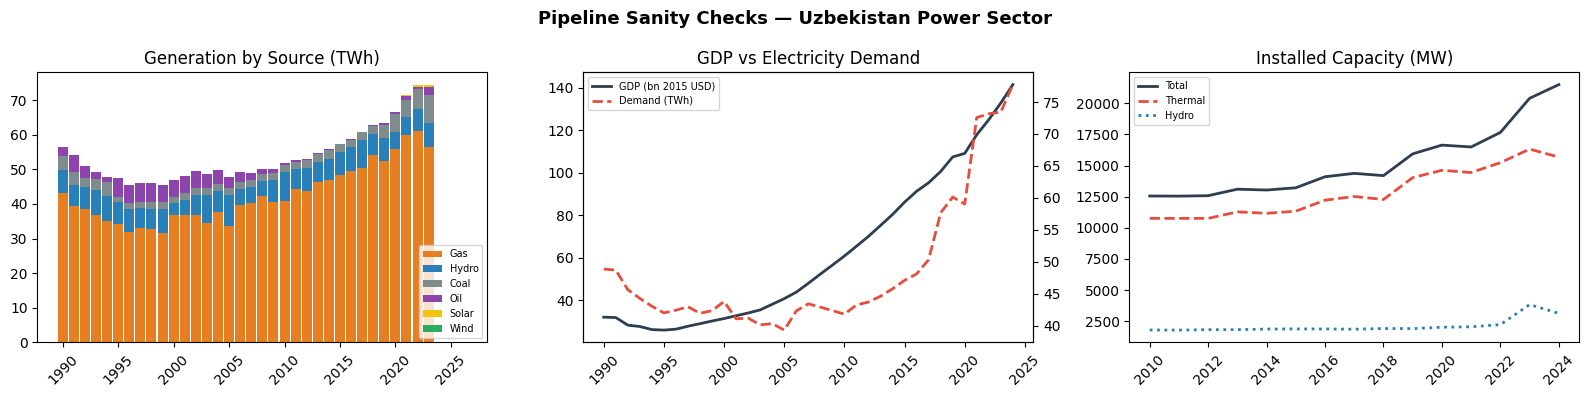

✓ Sanity plot saved.


In [72]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Pipeline Sanity Checks — Uzbekistan Power Sector', fontsize=13, fontweight='bold')

# Plot 1: Generation by source
ax = axes[0]
gen_cols   = ['gen_gas_twh', 'gen_hydro_twh', 'gen_coal_twh', 'gen_oil_twh', 'gen_solar_twh', 'gen_wind_twh']
gen_colors = ['#e67e22', '#2980b9', '#7f8c8d', '#8e44ad', '#f1c40f', '#27ae60']
gen_labels = ['Gas', 'Hydro', 'Coal', 'Oil', 'Solar', 'Wind']
bottom = np.zeros(len(master))
for col, color, label in zip(gen_cols, gen_colors, gen_labels):
    if col in master.columns:
        vals = master[col].fillna(0).values
        ax.bar(master.index, vals, bottom=bottom, color=color, label=label, width=0.9)
        bottom += vals
ax.set_title('Generation by Source (TWh)')
ax.legend(fontsize=7)
ax.tick_params(axis='x', rotation=45)

# Plot 2: GDP vs electricity demand
ax2 = axes[1]
ax2b = ax2.twinx()
if 'wb_gdp_const2015_bn_usd' in master.columns:
    ax2.plot(master.index, master['wb_gdp_const2015_bn_usd'], color='#2c3e50', lw=2, label='GDP (bn 2015 USD)')
if 'elec_consumption_twh_bridged' in master.columns:
    ax2b.plot(master.index, master['elec_consumption_twh_bridged'], color='#e74c3c', lw=2, ls='--', label='Demand (TWh)')
ax2.set_title('GDP vs Electricity Demand')
ax2.tick_params(axis='x', rotation=45)
lines1, lab1 = ax2.get_legend_handles_labels()
lines2, lab2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1+lines2, lab1+lab2, fontsize=7)

# Plot 3: Installed capacity
ax3 = axes[2]
if 'capacity_total_mw' in master.columns:
    ax3.plot(master.index, master['capacity_total_mw'], color='#2c3e50', lw=2, label='Total')
if 'capacity_thermal_mw' in master.columns:
    ax3.plot(master.index, master['capacity_thermal_mw'], color='#e74c3c', lw=2, ls='--', label='Thermal')
if 'capacity_hydro_mw' in master.columns:
    ax3.plot(master.index, master['capacity_hydro_mw'], color='#2980b9', lw=2, ls=':', label='Hydro')
ax3.set_title('Installed Capacity (MW)')
ax3.legend(fontsize=7)
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(DATA_PROCESSED, 'pipeline_sanity_check.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Sanity plot saved.')

---
## 12. Export Master Dataset

In [68]:
# ── Full dataset ───────────────────────────────────────────────────────────────
master_path = os.path.join(DATA_PROCESSED, 'master_dataset.csv')
master.to_csv(master_path)
print(f'✓ Full master dataset: {master_path}')
print(f'  {master.shape[0]} rows × {master.shape[1]} columns')

# ── Core columns only (lightweight version for dashboard) ─────────────────────
CORE_COLUMNS = [
    'elec_consumption_twh', 'elec_consumption_twh_bridged', 'elec_per_capita_mwh',
    'gen_total_twh', 'gen_total_twh_bridged',
    'gen_gas_twh', 'gen_hydro_twh', 'gen_coal_twh', 'gen_solar_twh', 'gen_wind_twh',
    'gen_fossil_twh', 'gen_renewable_twh', 're_penetration_pct', 'fossil_share_pct',
    'capacity_total_mw', 'capacity_thermal_mw', 'capacity_hydro_mw',
    'sc_solar_twh', 'sc_wind_twh',
    'irena_re_share_generation_pct', 'irena_re_share_capacity_pct',
    'sc_gas_prod_tj', 'sc_gas_cons_tj', 'gas_self_sufficiency_pct',
    'wb_co2_total_mt', 'wb_co2_power_mt', 'co2_intensity_power_gco2kwh',
    'wb_gdp_const2015_bn_usd', 'wb_gdp_growth_pct', 'wb_population', 'wb_urban_pop_pct',
    'is_preliminary', 'data_status',
]
core_cols_exist = [c for c in CORE_COLUMNS if c in master.columns]
master_core = master[core_cols_exist]

core_path = os.path.join(DATA_PROCESSED, 'master_dataset_core.csv')
master_core.to_csv(core_path)
print(f'\n✓ Core dataset: {core_path}')
print(f'  {master_core.shape[0]} rows × {master_core.shape[1]} columns')

print('\n' + '='*60)
print('Pipeline complete. Proceed to 02_eda.ipynb')
print('='*60)

✓ Full master dataset: ../data/processed/master_dataset.csv
  37 rows × 86 columns

✓ Core dataset: ../data/processed/master_dataset_core.csv
  37 rows × 32 columns

Pipeline complete. Proceed to 02_eda.ipynb
